In [1]:
import numpy as np
import xarray as xr
import cf_xarray as cfxr
import cf_xarray.units
import pint_xarray
import pint
from pint import application_registry as ureg
import matplotlib.pyplot as plt
import intake
import seaborn as sns, matplotlib.pyplot as plt
from os import environ
environ["PYTHONWARNINGS"] = "ignore"

In [2]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client
cluster = SLURMCluster(
    memory="100GB",
    processes=8,
    cores=8,
    walltime="02:00:00",
    queue="dcgp_usr_prod",
    account="ICT26_ESP",
    interface="ib0",
    env_extra=[
        "export OMP_NUM_THREADS=1",
        "export MKL_NUM_THREADS=1",
        "export NUMBA_NUM_THREADS=1",
    ],
    job_extra=[
        "--nodes=1",
        "--ntasks-per-node=8",
        "--hint=nomultithread",
    ],
    log_directory="logs/"
)

cluster.scale(16)
client = Client(cluster)

client

/leonardo/home/userexternal/ntilinin/.venvs/ocean2/lib/python3.11/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/leonardo/home/userexternal/ntilinin/.venvs/ocean2/lib/python3.11/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarnin

Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://10.128.0.7:8787/status,
Dashboard: http://10.128.0.7:8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.128.0.7:35959,Workers: 0
Dashboard: http://10.128.0.7:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [3]:
%%time 

experiment = 'AccessOm2IAF'

CPU times: user 7 μs, sys: 4 μs, total: 11 μs
Wall time: 19.8 μs


In [4]:
%%time 
CATALOG_sp = "/leonardo_scratch/fast/ICT26_ESP/ntilinin/access-om2-catalog/AccessOm2IAF_SPEEDY.json"

catalog_sp = intake.open_esm_datastore(
    CATALOG_sp,
    columns_with_iterables=[
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units",
    ]
)

CATALOG_jr = "/leonardo_scratch/fast/ICT26_ESP/ntilinin/access-om2-catalog/AccessOm2IAF_JRA55.json"

catalog_jr = intake.open_esm_datastore(
    CATALOG_jr,
    columns_with_iterables=[
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units",
    ]
)

CPU times: user 19.4 s, sys: 4.1 s, total: 23.5 s
Wall time: 54.1 s


In [5]:
variable = "surface_pot_temp"

ds_sp = catalog_sp.search(
    variable=variable,
    frequency="1mon"
).to_dask()

ds_jr = catalog_jr.search(
    variable=variable,
    frequency="1mon"
).to_dask()

sst_sp = ds_sp[variable]
sst_jr = ds_jr[variable]

In [6]:
sst_sp.time

<xarray.DataArray 'time' (time: 744)> Size: 6kB
array(['1958-01-16T12:00:00.000000000', '1958-02-15T00:00:00.000000000',
       '1958-03-16T12:00:00.000000000', ..., '2019-10-16T12:00:00.000000000',
       '2019-11-16T00:00:00.000000000', '2019-12-16T12:00:00.000000000'],
      shape=(744,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 6kB 1958-01-16T12:00:00 ... 2019-12-16T12:...
Attributes:
    long_name:       time
    cartesian_axis:  T
    calendar_type:   GREGORIAN
    bounds:          time_bnds

In [7]:
# Convert SST from K to °C
sst_sp = (sst_sp - 273.15).assign_attrs(
    units="degC",
    long_name="Sea Surface Temperature"
)
sst_jr = (sst_jr - 273.15).assign_attrs(
    units="degC",
    long_name="Sea Surface Temperature"
)

In [8]:
GRID_PATH = "/leonardo_scratch/fast/ICT26_ESP_0/ntilinin/access-om2/archive/1deg_speedy_iaf/output000/ocean"

area = xr.open_dataset(
    f"{GRID_PATH}/ocean-2d-area_t.nc"
)["area_t"]

area

<xarray.DataArray 'area_t' (yt_ocean: 300, xt_ocean: 360)> Size: 432kB
[108000 values with dtype=float32]
Coordinates:
  * yt_ocean  (yt_ocean) float64 2kB -77.88 -77.63 -77.38 ... 88.87 89.32 89.77
  * xt_ocean  (xt_ocean) float64 3kB -279.5 -278.5 -277.5 ... 77.5 78.5 79.5
Attributes:
    long_name:     tracer cell area
    units:         m^2
    valid_range:   [0.e+00 1.e+15]
    cell_methods:  time: point

In [9]:
# Ocean mask + area weights
weights = area.where(sst_sp.isel(time=0).notnull(), 0)

In [10]:
# # Global area-weighted annual mean SST
sst_ann_sp=sst_sp.groupby("time.year").mean("time")
sst_global_sp=sst_ann_sp.weighted(weights).mean(("yt_ocean","xt_ocean")).compute(scheduler="single-threaded")
sst_ann_jr=sst_jr.groupby("time.year").mean("time")
sst_global_jr=sst_ann_jr.weighted(weights).mean(("yt_ocean","xt_ocean")).compute(scheduler="single-threaded")

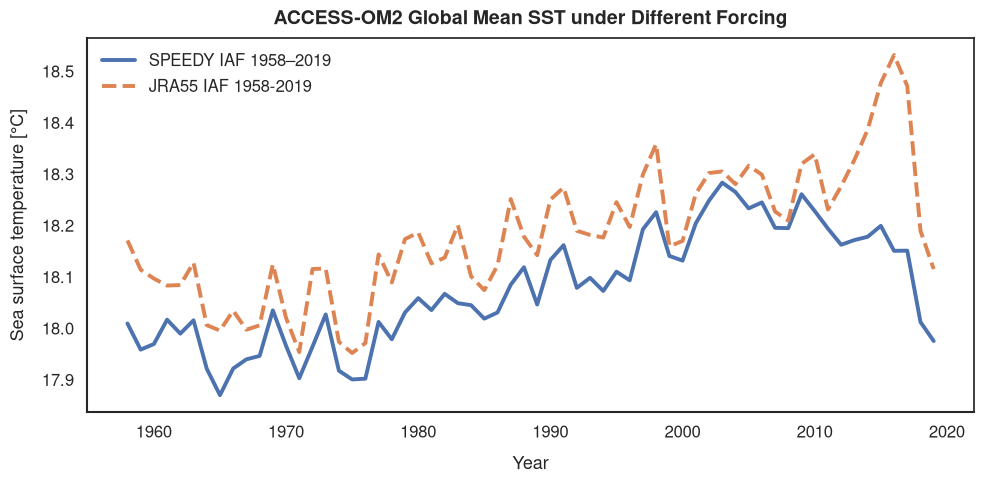

In [11]:
sns.set_theme(style="white"); plt.rcParams.update({"font.family": "Nimbus Sans"})

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(sst_global_sp.year, sst_global_sp, linewidth=2.8, label="SPEEDY IAF 1958–2019")
ax.plot(sst_global_jr.year, sst_global_jr, linewidth=2.8, linestyle="--", label="JRA55 IAF 1958-2019")

ax.set_title("ACCESS-OM2 Global Mean SST under Different Forcing", fontsize=14, pad=10, fontweight="bold")
ax.set_ylabel("Sea surface temperature [°C]", fontsize=13, labelpad=10)
ax.set_xlabel("Year", fontsize=13, labelpad=10)
ax.tick_params(axis="both", labelsize=12, width=1.2)

ax.spines["top"].set_visible(1); ax.spines["right"].set_visible(1)
ax.spines["left"].set_linewidth(1.5); ax.spines["bottom"].set_linewidth(1.5)

ax.legend(frameon=False, fontsize=12)
fig.tight_layout()
plt.savefig("figures/access_om2_global_mean_sst_df_IAF.png",
            dpi=300, bbox_inches="tight")
plt.show()

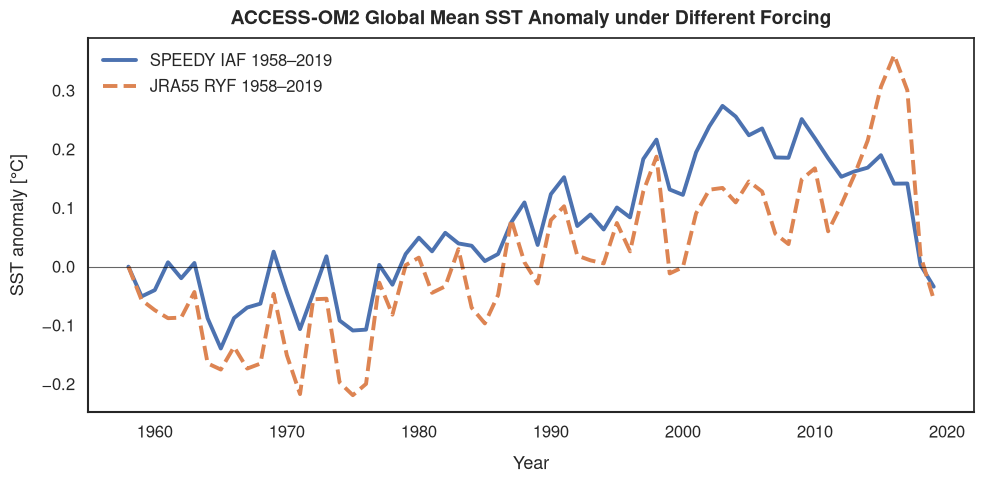

In [12]:
sst_anom_sp = sst_global_sp - sst_global_sp.isel(year=0)
sst_anom_jr = sst_global_jr - sst_global_jr.isel(year=0)

sns.set_theme(style="white"); plt.rcParams.update({"font.family": "Nimbus Sans"})

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(sst_anom_sp.year, sst_anom_sp, linewidth=2.8, label="SPEEDY IAF 1958–2019")
ax.plot(sst_anom_jr.year, sst_anom_jr, linewidth=2.8, linestyle="--", label="JRA55 RYF 1958–2019")
ax.axhline(0, linewidth=0.8, color="black", alpha=0.6)

ax.set_title("ACCESS-OM2 Global Mean SST Anomaly under Different Forcing", fontsize=14, pad=10, fontweight="bold")
ax.set_ylabel("SST anomaly [°C]", fontsize=13, labelpad=10)
ax.set_xlabel("Year", fontsize=13, labelpad=10)
ax.tick_params(axis="both", labelsize=12, width=1.2)

ax.spines["top"].set_visible(1); ax.spines["right"].set_visible(1)
ax.spines["left"].set_linewidth(1.5); ax.spines["bottom"].set_linewidth(1.5)

ax.legend(frameon=False, fontsize=12)
fig.tight_layout()
plt.savefig("figures/access_om2_global_mean_sst_anom_df_IAF.png",
            dpi=300, bbox_inches="tight")
plt.show()

In [13]:
client.close()
cluster.close()

/leonardo/home/userexternal/ntilinin/.venvs/ocean2/lib/python3.11/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/leonardo/home/userexternal/ntilinin/.venvs/ocean2/lib/python3.11/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarnin